In [1]:
import json
import os
import re
from time import time
from typing import Dict, Optional, Sequence, Set, Tuple, List
from itertools import product
from pathlib import Path
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plasso import PliableLasso
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, accuracy_score


In [2]:
#filename = "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_20_0.0.csv"  #need to save # F1_main=0.182 (P=1.000, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_20_0.5.csv" #need to save #F1_main=0.429 (P=0.750, R=0.300) | F1_inter=0.276 (P=0.211, R=0.400)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_20_0.8.csv" #need to save #F1_main=0.533 (P=0.800, R=0.400) | F1_inter=0.545 (P=0.500, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_500_0.0.csv" #started here: doesn't fit (converge), didnt create sol paths #same
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_500_0.5.csv" #same
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.05_500_0.8.csv"  # fitted, pl seems to be working better with higher correlation, bad fit though and bad f1 score # bad calibration F1_main=0.133 (P=0.200, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_20_0.0.csv" # good f1 score, didn't create sol paths, likely to very small y hat range # created sol paths , F1_main=0.706 (P=0.857, R=0.600) | F1_inter=0.727 (P=0.667, R=0.800)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_20_0.5.csv" # it fitted, small f1 #F1_main=0.778 (P=0.875, R=0.700) | F1_inter=0.465 (P=0.303, R=1.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_20_0.8.csv" # didnt create sol path, slughtly better inter f1 lower main f1 # didn't converge
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_500_0.0.csv" #fits fine but doesn't select interactions #F1_main=0.100 (P=0.100, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_500_0.5.csv" # realised here i might have not been using the right y_hat but the y_hat from a previous run, fit is bad, regularization is minimized ( chose small lambda)#allf1zeroandlistsofselectedempty
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.2_500_0.8.csv" #bad f1s #F1_main=0.125 (P=0.167, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_20_0.0.csv" #bad f1s, no selected interactions # good f1s : F1_main=0.667 (P=0.750, R=0.600) | F1_inter=0.700 (P=0.700, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_20_0.5.csv" #important dataset: f1s around 0.6 # F1_main=0.571 (P=1.000, R=0.400) | F1_inter=0.533 (P=0.800, R=0.400)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_20_0.8.csv" #important dataset: f1 inter around 0.5, f1 main low #F1_main=0.000 (P=0.000, R=0.000) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_500_0.0.csv" #bad f1s, better calibrated model # F1_main=0.167 (P=0.105, R=0.400) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_500_0.5.csv" #bad f1s, better calibrated model # F1_main=0.100 (P=0.100, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_250_0.5_500_0.8.csv" #F1_main=0.267 (P=0.400, R=0.200) | F1_inter=0.000 (P=0.000, R=0.000) #F1_main=0.125 (P=0.079, R=0.300) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_20_0.0.csv" #f1s arround 0.5 #F1_main=0.500 (P=0.667, R=0.400) | F1_inter=0.583 (P=0.500, R=0.700) #F1_main=0.533 (P=0.800, R=0.400) | F1_inter=0.444 (P=0.353, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_20_0.5.csv" #no selected interactions, f1 main 0.2 #F1_main=0.667 (P=0.636, R=0.700) | F1_inter=0.645 (P=0.476, R=1.000) #F1_main=0.533 (P=0.800, R=0.400) | F1_inter=0.444 (P=0.353, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_20_0.8.csv" #doesn't fit, class representation problem #same as before
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_500_0.0.csv" #medium f1 for mains and small for inter #F1_main=0.242 (P=0.174, R=0.400) | F1_inter=0.137 (P=0.076, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_500_0.5.csv" #low f1s #F1_main=0.273 (P=0.250, R=0.300) | F1_inter=0.324 (P=0.222, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.05_500_0.8.csv" #didn't fit, class representation problem #didn't create sol path F1_main=0.316 (P=0.333, R=0.300) | F1_inter=0.298 (P=0.189, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_20_0.0.csv" #F1_main=0.706 (P=0.857, R=0.600) | F1_inter=0.667 #F1_main=0.750 (P=1.000, R=0.600) | F1_inter=0.632 (P=0.667, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_20_0.5.csv" #important dataset!! F1_main=0.400 (P=0.600, R=0.300) | F1_inter=0.583 (P=0.500, R=0.700) # adding 0.4 to cv gave F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.737 (P=0.778, R=0.700) #F1_main=0.400 (P=0.600, R=0.300) | F1_inter=0.609 (P=0.538, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_20_0.8.csv" #important datasets!! F1_main=0.526 (P=0.556, R=0.500) | F1_inter=0.292 (P=0.184, R=0.700) # F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.320 (P=0.267, R=0.400) #F1_main=0.444 (P=0.500, R=0.400) | F1_inter=0.333 (P=0.219, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_500_0.0.csv" #F1_main=0.233 (P=0.152, R=0.500) | F1_inter=0.522 (P=0.462, R=0.600) #F1_main=0.429 (P=0.750, R=0.300) | F1_inter=0.571 (P=0.545, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_500_0.5.csv" #F1_main=0.242 (P=0.174, R=0.400) | F1_inter=0.444 (P=0.353, R=0.600) #F1_main=0.400 (P=0.600, R=0.300) | F1_inter=0.667 (P=0.750, R=0.600) #F1_main=0.429 (P=0.750, R=0.300) | F1_inter=0.667 (P=0.750, R=0.600) #F1_main=0.286 (P=0.273, R=0.300) | F1_inter=0.609 (P=0.538, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.2_500_0.8.csv" #too long to run, F1_main=0.500 (P=0.667, R=0.400) | F1_inter=0.581 (P=0.429, R=0.900) #F1_main=0.308 (P=0.667, R=0.200) | F1_inter=0.533 (P=0.800, R=0.400) #F1_main=0.167 (P=0.500, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000) #F1_main=0.273 (P=0.176, R=0.600) | F1_inter=0.390 (P=0.258, R=0.800)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_20_0.0.csv" # relatively good fit, F1_main=0.667 (P=0.636, R=0.700) | F1_inter=0.526 (P=0.556, R=0.500) #F1_main=0.824 (P=1.000, R=0.700) | F1_inter=0.737 (P=0.778, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_20_0.5.csv" #F1_main=0.737 (P=0.778, R=0.700) | F1_inter=0.640 (P=0.533, R=0.800) #F1_main=0.667 (P=1.000, R=0.500) | F1_inter=0.737 (P=0.778, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_20_0.8.csv" #didn't ctreate solution paths, F1_main=0.182 (P=1.000, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000) #F1_main=0.600 (P=0.600, R=0.600) | F1_inter=0.419 (P=0.273, R=0.900)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_500_0.0.csv" #F1_main=0.182 (P=1.000, R=0.100) | F1_inter=0.737 (P=0.778, R=0.700) (the smallest lambda the better) #F1_main=0.182 (P=1.000, R=0.100) | F1_inter=0.533 (P=0.800, R=0.400)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_500_0.5.csv" #F1_main=0.364 (P=0.333, R=0.400) | F1_inter=0.667 (P=0.750, R=0.600) #F1_main=0.320 (P=0.267, R=0.400) | F1_inter=0.571 (P=0.545, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_500_0.5_500_0.8.csv" #F1_main=0.364 (P=0.333, R=0.400) | F1_inter=0.667 (P=0.750, R=0.600) #F1_main=0.167 (P=0.500, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_20_0.0.csv" #good f1s, single fit, F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.818 (P=0.750, R=0.900) #F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.818 (P=0.750, R=0.900)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_20_0.5.csv" #means that none of your outer cross-validation folds produced results. This usually happens because all inner folds failed (e.g., due to class imbalance, solver errors, or other issues).
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_20_0.8.csv" #same
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_500_0.0.csv" #ValueError: attempt to get argmin of an empty sequence due to class imballance probably, run time about 7-8m # fit for one lambda F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.818 (P=0.750, R=0.900)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_500_0.5.csv" #F1_main=0.111 (P=0.125, R=0.100) | F1_inter=0.200 (P=0.133, R=0.400) #F1_main=0.000 (P=0.000, R=0.000) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.05_500_0.8.csv" #runned for 594m ~~10 hrs!!! | F1_main=0.300 (P=0.300, R=0.300) | F1_inter=0.242 (P=0.174, R=0.400) #F1_main=0.105 (P=0.111, R=0.100) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_20_0.0.csv"  #F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.667 (P=0.750, R=0.600) #F1_main=0.571 (P=1.000, R=0.400) | F1_inter=0.500 (P=0.667, R=0.400)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_20_0.5.csv" #F1_main=0.667 (P=1.000, R=0.500) | F1_inter=0.700 (P=0.700, R=0.700) #F1_main=0.667 (P=1.000, R=0.500) | F1_inter=0.818 (P=0.750, R=0.900)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_20_0.8.csv"  #F1_main=0.182 (P=1.000, R=0.100) | F1_inter=0.533 (P=0.800, R=0.400) #F1_main=0.000 (P=0.000, R=0.000) | F1_inter=0.000 (P=0.000, R=0.000)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_500_0.0.csv" #F1_main=0.267 (P=0.200, R=0.400) | F1_inter=0.333 (P=0.286, R=0.400) #F1_main=0.429 (P=0.750, R=0.300) | F1_inter=0.533 (P=0.800, R=0.400)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_500_0.5.csv" #F1_main=0.500 (P=0.667, R=0.400) | F1_inter=0.818 (P=0.750, R=0.900) #F1_main=0.476 (P=0.455, R=0.500) | F1_inter=0.640 (P=0.533, R=0.800)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.2_500_0.8.csv" # F1_main=0.471 (P=0.571, R=0.400) | F1_inter=0.486 (P=0.333, R=0.900) #F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.737 (P=0.778, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_20_0.0.csv" #relatively calibrated model | F1_main=0.824 (P=1.000, R=0.700) | F1_inter=0.762 (P=0.727, R=0.800) #F1_main=0.778 (P=0.875, R=0.700) | F1_inter=0.632 (P=0.667, R=0.600)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_20_0.5.csv" #F1_main=0.571 (P=1.000, R=0.400) | F1_inter=0.818 (P=0.750, R=0.900) #F1_main=0.462 (P=1.000, R=0.300) | F1_inter=0.737 (P=0.778, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_20_0.8.csv" #F1_main=0.667 (P=1.000, R=0.500) | F1_inter=0.692 (P=0.562, R=0.900) #F1_main=0.571 (P=1.000, R=0.400) | F1_inter=0.583 (P=0.500, R=0.700)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_500_0.0.csv" #F1_main=0.667 (P=1.000, R=0.500) | F1_inter=0.706 (P=0.857, R=0.600) #F1_main=0.750 (P=1.000, R=0.600) | F1_inter=0.842 (P=0.889, R=0.800)
#filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_500_0.5.csv" #F1_main=0.519 (P=0.412, R=0.700) | F1_inter=0.737 (P=0.778, R=0.700) #F1_main=0.667 (P=0.636, R=0.700) | F1_inter=0.783 (P=0.692, R=0.900)
filename =  "C:/Users/enthe/Desktop/Thesis/data/simulated_data/simulated_dataset_1000_0.5_500_0.8.csv" # 700m! | F1_main=0.429 (P=0.750, R=0.300) | F1_inter=0.533 (P=0.800, R=0.400) #F1_main=0.571 (P=0.545, R=0.600) | F1_inter=0.500 (P=0.389, R=0.700)

In [3]:
#extract parameters n,prev,p,rho from filename and locate corresponding truth file
# pull n, prev, p, rho from the filename
stem = Path(filename).stem  # simulated_dataset_{n}_{prev}_{p}_{rho}
n_s, prev_s, p_s, rho_s = stem.split("_")[-4:]
n, prev, p, rho = int(n_s), float(prev_s), int(p_s), float(rho_s)
print(f"n: {n}, prev: {prev}, p: {p}, rho: {rho}")

truth_file = str(Path(filename).with_name(
    Path(filename).name.replace("simulated_dataset_", "truth_simulated_dataset_").replace(".csv", ".json")
))
with open(truth_file) as f: truth = json.load(f)
print(f"Truth file located at: {truth_file}")

chosen_file = str(Path(filename).with_name(
    Path(filename).name.replace("simulated_dataset_", "chosen_simulated_dataset_").replace(".csv", ".json")
))
#with open(chosen_file) as f: chosen = json.load(f) #used to compare old with new chosen
#print(f"Chosen file located at: {chosen_file}")


n: 1000, prev: 0.5, p: 500, rho: 0.8
Truth file located at: C:\Users\enthe\Desktop\Thesis\data\simulated_data\truth_simulated_dataset_1000_0.5_500_0.8.json


In [4]:
# read simulated dataset and get y and x features
df = pd.read_csv(filename)
X = df[[f"X{i}" for i in range(1, p+1)]]
#print(X.head())
y = df["y"]
#print(y.head())

In [5]:
#read truth file and get true z indices and true main effects and interaction pairs

with open(truth_file) as f: t = json.load(f)
# true z indices, main-effect indices, and interaction pairs
z_idx = t["interaction_core_idx"]
print(z_idx)
print(f"True interaction core indices: {z_idx}")
main_idx = t["main_idx"]
interaction_pairs = [tuple(p) for p in t["interaction_pairs"]]

# (optional) coefficients as handy dicts
beta = {int(k): float(v) for k, v in t["beta"].items()}                   # main effects
gamma = {tuple(map(int, k.split("_"))): float(v) for k, v in t["gamma"].items()}  # interaction effects
print(f"interaaction coefficients: {gamma}")

[459, 484, 13, 225, 129]
True interaction core indices: [459, 484, 13, 225, 129]
interaaction coefficients: {(459, 484): -0.19931545224054534, (459, 13): -0.4575052190641792, (459, 225): 0.16282852863409422, (459, 129): 0.416545442889049, (484, 13): -0.09701501597205182, (484, 225): 0.31630743737748324, (484, 129): -0.696449307470529, (13, 225): 0.04454309149620982, (13, 129): -0.23595044992988937, (225, 129): -1.0868189011364018}


In [6]:
#set parameters for fine tuning. for sure mit and maybe alpha and cv
# hyperparams / settings
ALPHAS     = [0.1, 0.3, 0.5, 0.7]      # try a few; tweak as you like
MITS       = [5, 10, 20, 50, 100]      # max # interaction terms
N_SPLITS   = 5
#RANDOM_STATE = 42
#PL_CV      = 0.2                       # internal holdout for PliableLasso (set 1 to disable if supported)
#THRESH     = 1e-8
CVS    = [0.05, 0.1, 0.2, 0.3, 0.4]  

N_OUTER, N_INNER, RANDOM_STATE, THR= 5, 5, 42, 1e-8


# truth-driven targets (expects dict `t` from your truth JSON)
Z_IDX  = t["interaction_core_idx"]     # or set to None to use all features as Z
M_TRUE = set(map(int, t["main_idx"]))
I_TRUE = set(map(frozenset, t["interaction_pairs"]))


In [ ]:
#run a cross-validated grid search for best hyperparameters that deliver best F1 score on interaction recovery. store the best model according the previously mentioned rule. store the selected main effects and interactions the correspinding coefficients, the parameters for which that was succeded and the f1 scores for main effect recovery and interaction recovery.
def _f1(T, P):
    tp = len(T & P); prec = tp / len(P) if P else 0.0; rec = tp / len(T) if T else 0.0
    return (0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec), prec, rec)

#pulls out which features your fitted model actually “uses.”
def _selected_sets(model, p, z_idx, thr=1e-8):
    import numpy as np
    z = np.asarray(z_idx, int)

    # pull coeffs without boolean chaining on arrays
    beta = getattr(model, "beta_", None)
    if beta is None: beta = getattr(model, "beta", None)
    if beta is None: beta = getattr(model, "coef_", None)

    theta = getattr(model, "theta_", None)
    if theta is None: theta = getattr(model, "theta", None)

    # main effects
    mains = set()
    if beta is not None:
        b = np.asarray(beta, float).ravel()
        for j in range(min(p, b.size)):
            if abs(b[j]) > thr:
                mains.add(j)

    # interactions
    inter = set()
    if theta is not None:
        T = np.asarray(theta, float)
        for i in range(p):
            for jj in range(T.shape[1]):
                if abs(T[i, jj]) > thr:
                    inter.add(frozenset((i, int(z[jj]))))

    return mains, inter



y_bin = (y.values.ravel() > 0.5).astype(int)
outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)

OUTER_ROWS, OUTER_PARAMS = [], []

for k, (tr, te) in enumerate(outer_cv.split(X, y_bin), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    inner_cv = StratifiedKFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_STATE + k)
    inner_scores = []

    # ---------- inner CV: mean over folds per (alpha, mit, cv) ----------
    for a in ALPHAS:
        for mit in MITS:
            for cvp in CVS:
                f1i, reci = [], []
                for itr, ival in inner_cv.split(Xtr, (ytr.values.ravel() > 0.5).astype(int)):
                    Xi, yi = Xtr.iloc[itr], ytr.iloc[itr]
                    # Check class representation in training set
                    y_train_bin = (yi.values.ravel() > 0.5).astype(int)
                    unique_classes = np.unique(y_train_bin)
                    if len(unique_classes) < 2:
                        # Skip this fold if only one class is present
                        continue
                    X_np = Xi.to_numpy(); Z = X_np[:, np.asarray(Z_IDX, int)]
                    m = PliableLasso(alpha=a, cv=cvp, eps=1e-4, normalize=True,
                                     max_interaction_terms=mit, verbose=False)
                    try:
                        m.fit(X_np, Z, yi.to_numpy().ravel())
                    except ValueError:
                        continue  # skip this fold if solver fails
                    _, inter = _selected_sets(m, p, Z_IDX, THR)
                    fi, _, ri = _f1(I_TRUE, inter)
                    f1i.append(fi); reci.append(ri)

                if not f1i:  # no valid inner scores for this combo
                    continue

                inner_scores.append({
                    "alpha": a, "mit": mit, "cv": cvp,
                    "mean_F1_inter": float(np.mean(f1i)),
                    "mean_recall_inter": float(np.mean(reci)),
                })
    # skip this outer fold entirely if no inner combo survived
    if not inner_scores:
        continue       
    # pick best params by mean F1_inter (then mean recall_inter, then min mit)
    best = max(inner_scores, key=lambda r: (r["mean_F1_inter"], r["mean_recall_inter"], -r["mit"], -r["cv"]))
    #OUTER_PARAMS.append((best["alpha"], best["mit"], best["cv"]))

    # -------- outer evaluation: fit on outer-train with inner-best, report test metric --------
    X_np = Xtr.to_numpy(); Z = X_np[:, np.asarray(Z_IDX, int)]
    m = PliableLasso(alpha=best["alpha"], cv=best["cv"], eps=1e-4, normalize=True,
                     max_interaction_terms=best["mit"], verbose=False)
    #m.fit(X_np, Z, ytr.to_numpy().ravel())
    try:
        m.fit(X_np, Z, ytr.to_numpy().ravel())
    except ValueError:
        continue  # skip (alpha, mit) for this fold
    OUTER_PARAMS.append((best["alpha"], best["mit"], best["cv"]))  # <-- move here, after fit succeeds

    mains, inter = _selected_sets(m, p, Z_IDX, THR)
    F1i, Pi, Ri = _f1(I_TRUE, inter); F1m, _, _ = _f1(M_TRUE, mains)

    OUTER_ROWS.append({
        "fold": k, "alpha": best["alpha"], "max_interaction_terms": best["mit"], "cv": best["cv"],
        "outer_F1_inter": F1i, "outer_recall_inter": Ri, "outer_precision_inter": Pi,
        "outer_F1_main": F1m
    })
# guard before summarizing
if not OUTER_ROWS:
    raise ValueError("No outer test results gathered.")

# summaries
NESTED_OUTER_RESULTS = pd.DataFrame(OUTER_ROWS).sort_values("fold").reset_index(drop=True)
NESTED_OUTER_MEAN = NESTED_OUTER_RESULTS[
    ["outer_F1_inter","outer_recall_inter","outer_precision_inter","outer_F1_main"]
].mean().to_dict()

# suggested final params: mode of (alpha, mit, cv); tie-break by mean outer F1 among ties
cnt = Counter(OUTER_PARAMS); top = max(cnt.values())
cands = [pm for pm, c in cnt.items() if c == top]
if len(cands) > 1:
    means = {
        pm: NESTED_OUTER_RESULTS.loc[
                (NESTED_OUTER_RESULTS["alpha"] == pm[0]) &
                (NESTED_OUTER_RESULTS["max_interaction_terms"] == pm[1]) &
                (NESTED_OUTER_RESULTS["cv"] == pm[2]),
                "outer_F1_inter"
            ].mean()
        for pm in cands
    }
    chosen = max(means.items(), key=lambda kv: kv[1])[0]
else:
    chosen = cands[0]

NESTED_SUGGESTED_PARAMS = {"alpha": chosen[0], "max_interaction_terms": chosen[1], "cv": chosen[2]}


Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction Terms reached.
Maximum Interaction 

In [ ]:
# Refit on ALL data with the chosen params 


# params = (NESTED_SUGGESTED_PARAMS if 'NESTED_SUGGESTED_PARAMS' in globals() and NESTED_SUGGESTED_PARAMS
#           else CV_BEST_PARAMS)
# assert params, "No selected params found (NESTED_SUGGESTED_PARAMS or CV_BEST_PARAMS)."

assert 'NESTED_SUGGESTED_PARAMS' in globals() and NESTED_SUGGESTED_PARAMS, "No selected params found (NESTED_SUGGESTED_PARAMS)."
params = NESTED_SUGGESTED_PARAMS


X_np = X.to_numpy()
Z_all = X_np[:, np.asarray(Z_IDX, int)]

#cv_refit = params.get("cv", PL_CV)   

cv_refit = params.get("cv", params["cv"])  


best_model = PliableLasso(
    alpha=params["alpha"],
    cv=params["cv"],
    eps=1e-4,
    normalize=True,
    max_interaction_terms=params["max_interaction_terms"],
    verbose=False
)
print("a is", params["alpha"])
print(best_model.cv)
t0 = time()
print(X_np.shape)
print(Z_all.shape)
print(y.to_numpy().ravel().shape)
best_model.fit(X_np, Z_all, y.to_numpy().ravel())

fit_time = time() - t0

#add mse and accuracy here and in saved model


a is 0.1
0.05
(1000, 500)
(1000, 5)
(1000,)
Maximum Interaction Terms reached.


In [ ]:
# Get predictions (scores)
y_true = y.to_numpy().ravel()
y_pred = best_model.predict(X_np, Z_all).ravel()

# For binary classification, threshold at 0.5 to get predicted labels
y_pred_label = (y_pred > 0.5).astype(int)

# Calculate metrics
mse = mean_squared_error(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred_label)

print(f"MSE: {mse:.4f}, Accuracy: {accuracy:.4f}")

MSE: 0.1985, Accuracy: 0.6890


In [ ]:
#prints

# params (prefer CV_BEST_PARAMS if present, else nested)
params = (CV_BEST_PARAMS if 'CV_BEST_PARAMS' in globals() and CV_BEST_PARAMS else
          NESTED_SUGGESTED_PARAMS if 'NESTED_SUGGESTED_PARAMS' in globals() else None)
if params:
    cv_txt = f", cv={params['cv']}" if 'cv' in params else ""
    print(f"Best params: alpha={params['alpha']}, mit={params['max_interaction_terms']}{cv_txt}")

# coefficients from the model 
beta = getattr(best_model, "beta_", None)
if beta is None: beta = getattr(best_model, "beta", None)
if beta is None: beta = getattr(best_model, "coef_", None)
theta = getattr(best_model, "theta_", None)
if theta is None: theta = getattr(best_model, "theta", None)
intercept = getattr(best_model, "intercept_", None)

b = np.asarray(beta, float).ravel() if beta is not None else np.zeros(p)
T = np.asarray(theta, float) if theta is not None else np.zeros((p, len(Z_IDX)))

# selected sets
mains = {j for j in range(min(p, b.size)) if abs(b[j]) > THR}
z = np.asarray(Z_IDX, int)
inter = set()
for i in range(p):
    for jj in range(T.shape[1]):
        coef = T[i, jj]
        if abs(coef) > THR:
            inter.add(frozenset((i, int(z[jj]))))

# pretty prints
print(f"Intercept: {intercept}")
print(f"Selected mains ({len(mains)}): {sorted(mains)}")
print("Top main coefs (abs):",
      sorted(((j, float(b[j])) for j in mains), key=lambda x: abs(x[1]), reverse=True)[:10])

gamma = {}
for i in range(p):
    for jj in range(T.shape[1]):
        coef = T[i, jj]
        if abs(coef) > THR:
            gamma[(i, int(z[jj]))] = float(coef)

keys_preview = list(gamma.keys())[:10]
print(f"Selected interactions ({len(gamma)}): {keys_preview}{' ...' if len(gamma) > 10 else ''}")
print("Top interaction coefs (abs):",
      sorted(gamma.items(), key=lambda x: abs(x[1]), reverse=True)[:10])

# F1 vs truth
def _f1(T_set, P_set):
    tp = len(T_set & P_set); pr = tp / len(P_set) if P_set else 0.0; rc = tp / len(T_set) if T_set else 0.0
    return (0.0 if pr + rc == 0 else 2 * pr * rc / (pr + rc), pr, rc)

F1m, Pm, Rm = _f1(M_TRUE, mains)
F1i, Pi, Ri = _f1(I_TRUE, inter)
print(f"F1_main={F1m:.3f} (P={Pm:.3f}, R={Rm:.3f}) | F1_inter={F1i:.3f} (P={Pi:.3f}, R={Ri:.3f})")

Best params: alpha=0.1, mit=20, cv=0.05
Intercept: None
Selected mains (11): [129, 130, 134, 136, 169, 219, 220, 221, 225, 226, 482]
Top main coefs (abs): [(220, 0.06932848921823039), (134, 0.018846356063157186), (169, -0.006976223682585375), (219, 0.004893243465972883), (136, 0.0037685015656360164), (482, -0.002157136339335187), (221, 0.0016100191338336667), (130, 4.925753709434331e-05), (226, 1.4209261743773171e-05), (129, 1.0397445199054402e-05)]
Selected interactions (19): [(129, 459), (129, 484), (129, 13), (129, 225), (129, 129), (130, 459), (130, 484), (130, 13), (130, 225), (130, 129)] ...
Top interaction coefs (abs): [((129, 225), -0.00022149007129858544), ((225, 129), -0.00012101985281394215), ((129, 459), 0.00010755695249220871), ((129, 484), -7.875130363119226e-05), ((130, 225), -7.86655078348981e-05), ((129, 13), -5.9083981709581326e-05), ((226, 129), -5.3546828755624116e-05), ((225, 484), 5.316873716480356e-05), ((129, 129), -5.111409966013386e-05), ((130, 459), 3.5880199

In [ ]:
print("y_true shape:", y_true.shape, "min:", np.min(y_true), "max:", np.max(y_true))
y_hat = (best_model.predict(X_np, Z_all)
         if hasattr(best_model, "predict_proba")
         else best_model.predict(X_np, Z_all)).ravel()
print("y_hat shape:", y_hat.shape, "min:", np.min(y_hat), "max:", np.max(y_hat))
print("Any NaN in y_true?", np.isnan(y_true).any())
print("Any NaN in y_hat?", np.isnan(y_hat).any())
print("Any nonzero coefficients?", np.any(np.abs(b) > 1e-8), np.any(np.abs(T) > 1e-8))

y_true shape: (1000,) min: 0 max: 1
y_hat shape: (1000,) min: -0.0974346856420578 max: 1.1872575100481424
Any NaN in y_true? False
Any NaN in y_hat? False
Any nonzero coefficients? True True


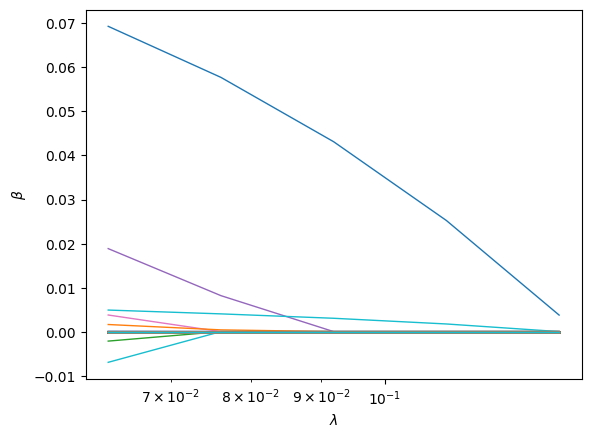

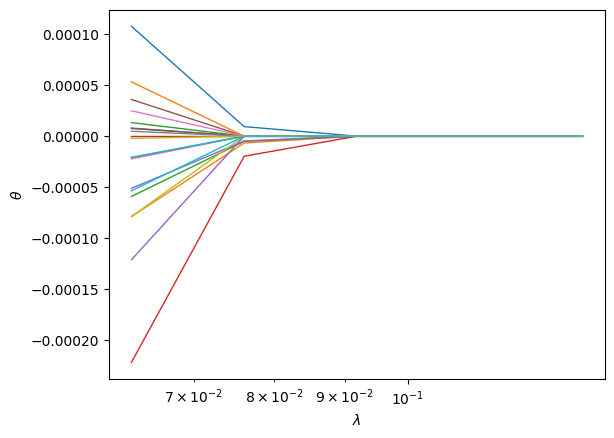

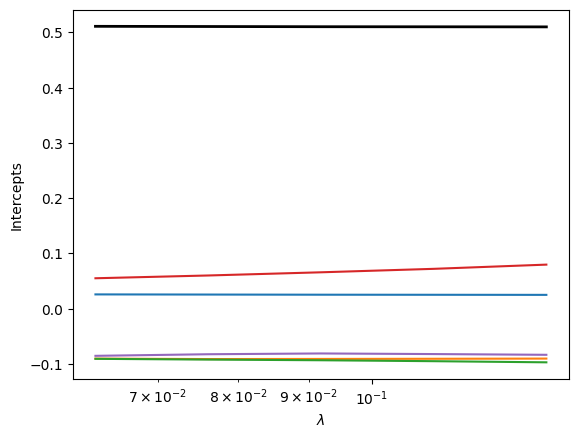

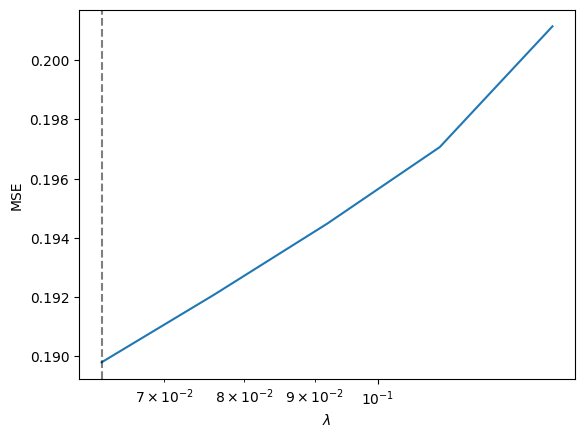

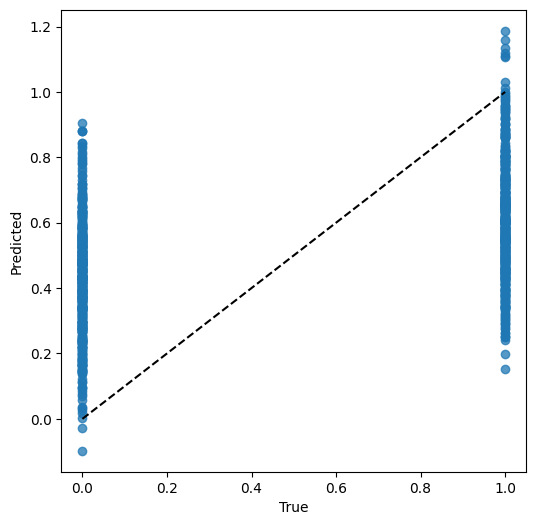

In [ ]:
## plots
#===========================================
best_model.plot_coef_paths()
plt.show()

best_model.plot_interaction_paths()
plt.show()

best_model.plot_intercepts_path()
plt.show()

best_model.plot_score_path()
plt.show()
y_true = y.to_numpy().ravel()
y_hat = (best_model.predict(X_np, Z_all)
         if hasattr(best_model, "predict_proba")
         else best_model.predict(X_np, Z_all)).ravel()
plt.figure(figsize=(6, 6))
plt.plot(y_true, y_hat, 'o', alpha=0.75)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--', color='black')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.show() 


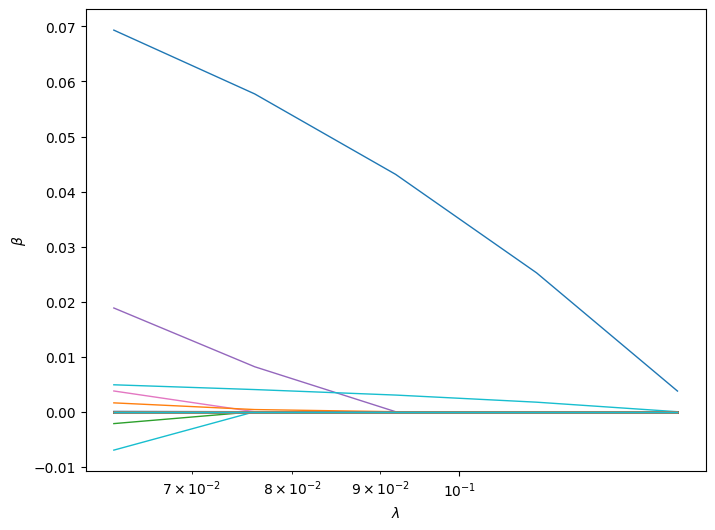

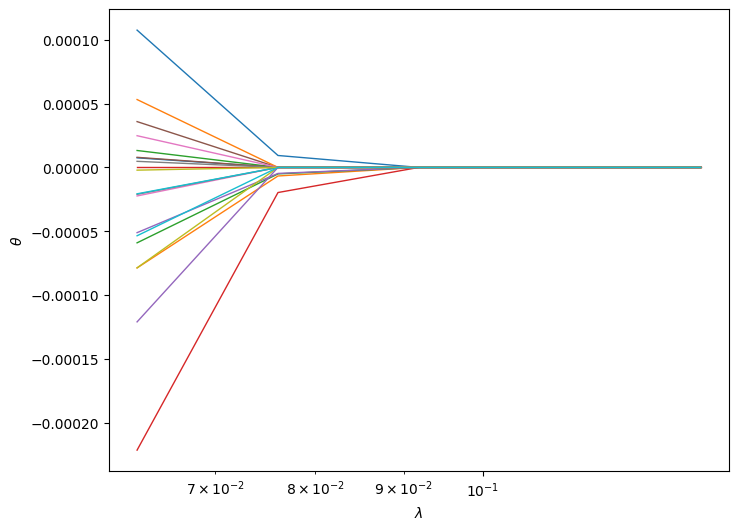

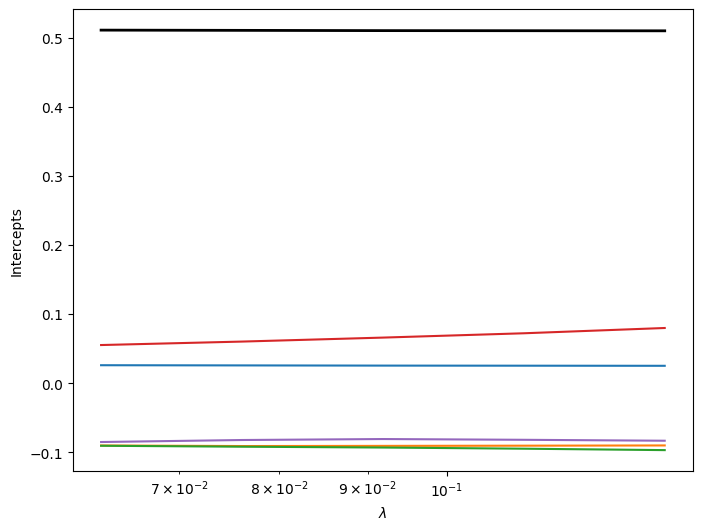

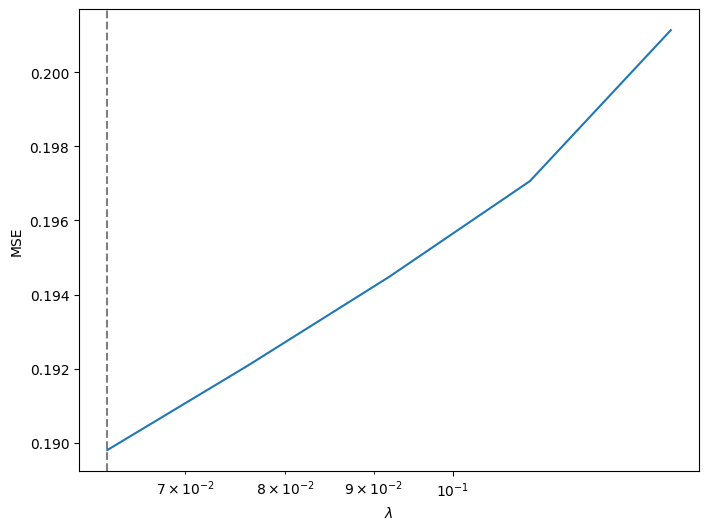

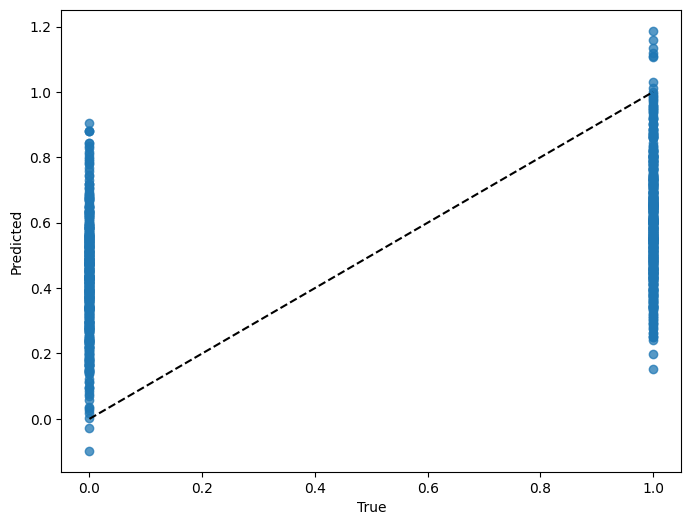

In [ ]:
plt.figure(figsize=(8, 6))  
best_model.plot_coef_paths()
plt.show()

plt.figure(figsize=(8, 6))
best_model.plot_interaction_paths()
plt.show()

plt.figure(figsize=(8, 6))
best_model.plot_intercepts_path()
plt.show()

plt.figure(figsize=(8, 6))
best_model.plot_score_path()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(y_true, y_hat, 'o', alpha=0.75)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--', color='black')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.show()

beta path shape: (5, 500)
beta path min/max: -0.006976223682585375 0.06932848921823039
theta path shape: (5, 500, 5)
theta path min/max: -0.00022149007129858544 0.00010755695249220871


(-0.001, 0.001)

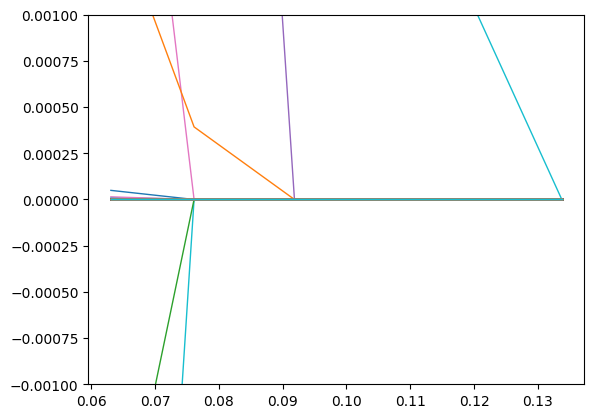

In [ ]:
# Print the coefficient path shapes and max/min values
print("beta path shape:", best_model.paths['beta'].shape)
print("beta path min/max:", np.min(best_model.paths['beta']), np.max(best_model.paths['beta']))
print("theta path shape:", best_model.paths['theta'].shape)
print("theta path min/max:", np.min(best_model.paths['theta']), np.max(best_model.paths['theta']))

plt.plot(best_model.paths['lam'], best_model.paths['beta'], linewidth=1)
plt.ylim(-1e-3, 1e-3)  

In [ ]:
#save best model, parameters, selected main effects and interactions, coefficients, f1 scores to results\fit\best_model_simulated_dataset_{n}_{prev}_{p}_{rho}.json

# Prepare output directory and filename
out_dir = os.path.join("results", "fit")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(
    out_dir,
    f"best_model_simulated_dataset_{n}_{prev}_{p}_{rho}.json"
)

# Prepare data to save
save_dict = {
    "params": params,
    "selected_mains": sorted(mains),
    "selected_interactions": [list(t) for t in gamma.keys()],
    "main_coefficients": {int(j): float(b[j]) for j in mains},
    "interaction_coefficients": {f"{i}_{j}": float(coef) for (i, j), coef in gamma.items()},
    "F1_main": F1m,
    "precision_main": Pm,
    "recall_main": Rm,
    "F1_inter": F1i,
    "precision_inter": Pi,
    "recall_inter": Ri,
    "fit_time_seconds": fit_time,
    "mse": mse,
    "accuracy": accuracy,
}

# Save to JSON
with open(out_path, "w") as f:
    json.dump(save_dict, f, indent=2)
print(f"Saved best model summary to {out_path}")

Saved best model summary to results\fit\best_model_simulated_dataset_1000_0.5_500_0.8.json
